In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000           80

C:\Users\Hp\AppData\Local\Temp\ipykernel_2848\2373953960.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


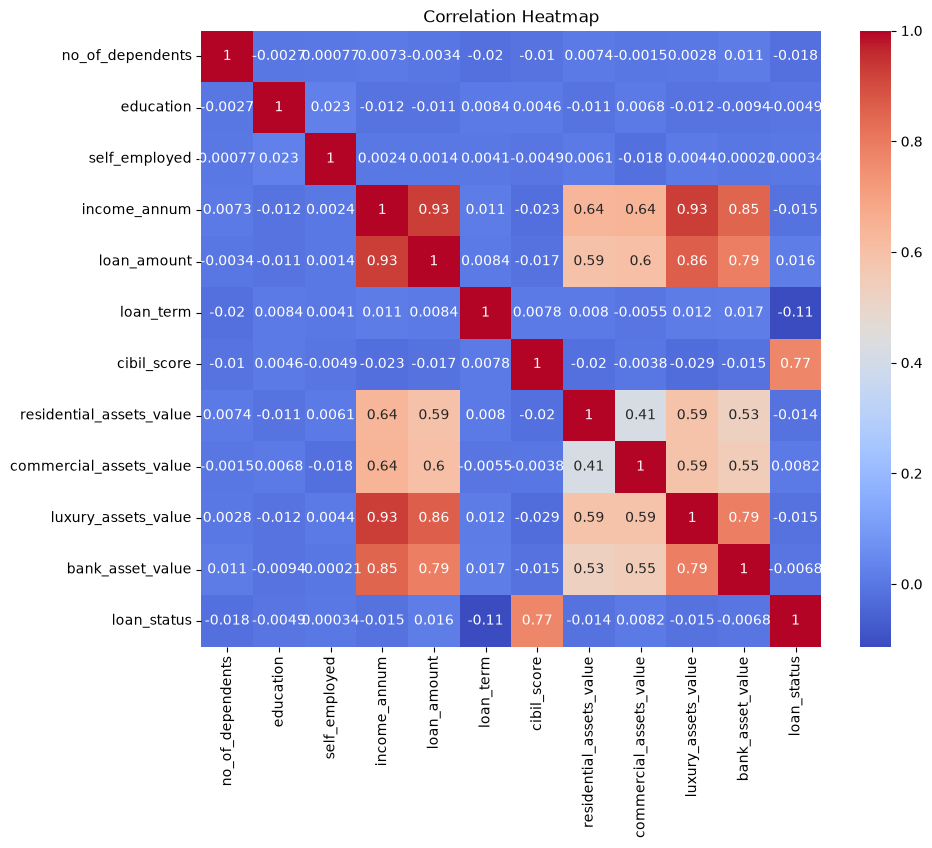


Accuracy: 98.36 %

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



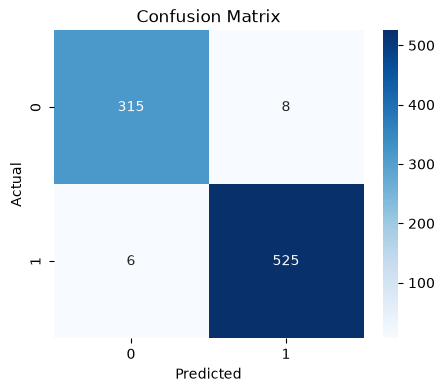


Model saved successfully as model.pkl


In [6]:

# SMART LENDER - LOAN APPROVAL PREDICTION
# notebook.ipynb

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load Dataset
df = pd.read_csv("DataSet/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
print(df.head())

# Step 3: Dataset Information
print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

# Step 4: Remove spaces from text columns
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

# Step 5: Encode Categorical Data
encoder = LabelEncoder()

df["education"] = encoder.fit_transform(df["education"])
df["self_employed"] = encoder.fit_transform(df["self_employed"])

df["loan_status"] = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

# Step 6: Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop("loan_id", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# Step 7: Features and Target
X = df.drop(["loan_id", "loan_status"], axis=1)
y = df["loan_status"]

# Step 8: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Step 9: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 10: Train Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Step 11: Prediction
predictions = model.predict(X_test)

# Step 12: Accuracy
accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Step 13: Classification Report
print("\nClassification Report")
print(classification_report(y_test, predictions))

# Step 14: Confusion Matrix
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 15: Save Model
joblib.dump(model, "model.pkl")

print("\nModel saved successfully as model.pkl")

In [8]:
import joblib

joblib.dump(model, "Flask/model.pkl")
joblib.dump(scaler, "Flask/scaler.pkl")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [10]:
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']
